# Multiclass SVM (One-vs-Rest) for Credit Risk Grade Prediction (A–G)

## What problem are we solving?

We want to predict the **credit risk grade** of a loan applicant:

- **Target:** $\text{grade\_idx} \in \{0,1,2,3,4,5,6\}$, mapping $A \to 0, \dots, G \to 6$  
- **Task type:** Multiclass classification (7 classes)  
- **Features:** 22 pre-issuance features (numeric + categorical)  

This mimics a real-world credit risk problem: we use only borrower/application attributes available at (or before) loan issuance.

---

## What algorithm are we implementing?

### Support Vector Machines (SVM) — Linear SVM

A **linear SVM** tries to find a hyperplane:

$$
f(x) = w^\top x + b
$$

that separates the classes with a **maximum margin**.

For **binary classification**, we use the **hinge loss**:

$$
\ell(x_i, y_i) = \max(0, 1 - y_i (w^\top x_i + b))
$$

with $y_i \in \{-1, +1\}$.

The **primal objective** we optimize is:

$$
J(w,b) = \frac{1}{2} \|w\|^2 + C \cdot \text{mean} \big( \max(0, 1 - y_i (w^\top x_i + b)) \big)
$$

where $C$ controls the trade-off:

- small $C$ → wider margin, more tolerance for errors  
- large $C$ → stricter classification, smaller margin

---

## Multiclass handling: One-vs-Rest (OvR)

SVM is naturally a binary classifier. To handle multiple classes:

- Train **one binary SVM per class**  
- For class $k$: treat class $k$ as $+1$, all others as $-1$  
- At prediction time: compute scores for all classes and select the class with the **highest score**


In [ ]:
from google.colab import drive
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

print("Train CSV exists:", train_csv.exists(), train_csv)
print("Dev CSV exists:", dev_csv.exists(), dev_csv)
print("Test CSV exists:", test_csv.exists(), test_csv)


DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True
Train CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists: True /content/drive/MyDrive/ML Project/Data/Test/test.csv


## Load train / dev / test data

We read the CSV files from Google Drive and do basic sanity checks:
- shape
- column names
- class distribution (grade_idx)


In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", list(train_df.columns))

# Basic check: target column exists
assert "grade_idx" in train_df.columns, "Expected 'grade_idx' in train.csv"
assert "grade_idx" in dev_df.columns, "Expected 'grade_idx' in dev.csv"
assert "grade_idx" in test_df.columns, "Expected 'grade_idx' in test.csv"

# Class distribution
print("\nTrain grade_idx counts:\n", train_df["grade_idx"].value_counts().sort_index())
print("\nDev grade_idx counts:\n", dev_df["grade_idx"].value_counts().sort_index())
print("\nTest grade_idx counts:\n", test_df["grade_idx"].value_counts().sort_index())

train_df.head()


Train shape: (59619, 24)
Dev shape: (12775, 24)
Test shape: (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Train grade_idx counts:
 grade_idx
0    8517
1    8517
2    8517
3    8517
4    8517
5    8517
6    8517
Name: count, dtype: int64

Dev grade_idx counts:
 grade_idx
0    1825
1    1825
2    1825
3    1825
4    1825
5    1825
6    1825
Name: count, dtype: int64

Test grade_idx counts:
 grade_idx
0    1826
1    1826
2    1826
3    1826
4    1826
5    1826
6    1826
Name: count, dtype: int64


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0
3,E,4,debt_consolidation,RENT,Source Verified,IL,15000.0,60.0,2.0,30000.0,...,38.0,0.0,13211.0,63.5,0.0,0.0,0.0,0.0,132.008214,672.0
4,E,4,debt_consolidation,RENT,Verified,MD,15200.0,60.0,4.0,38000.0,...,10.0,0.0,5600.0,70.0,0.0,0.0,0.0,0.0,223.934292,697.0


## Preprocessing for SVM

SVMs are sensitive to feature scales, so we will do the following:

1. **One-hot encode** categorical columns:  
   - `purpose`, `home_ownership`, `verification_status`, `addr_state`  

2. **Standardize** numeric columns using **train statistics**:

$$
x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

3. Make sure the dev and test sets have the **exact same columns** as the training set (using `reindex`).



In [ ]:
LABEL_COL = "grade_idx"
DROP_LABELS = ["grade", "grade_idx"]

cat_cols = ["purpose", "home_ownership", "verification_status", "addr_state"]

# Everything else except labels is treated as numeric
feature_cols = [c for c in train_df.columns if c not in DROP_LABELS]
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)
print("Total features (before one-hot):", len(feature_cols))

def make_xy(df):
    X = df[feature_cols].copy()
    y = df[LABEL_COL].astype(int).to_numpy()
    return X, y

X_train_raw, y_train = make_xy(train_df)
X_dev_raw,   y_dev   = make_xy(dev_df)
X_test_raw,  y_test  = make_xy(test_df)

# One-hot on TRAIN, then align DEV/TEST to TRAIN columns
X_train_oh = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=False)
X_dev_oh   = pd.get_dummies(X_dev_raw,   columns=cat_cols, drop_first=False)
X_test_oh  = pd.get_dummies(X_test_raw,  columns=cat_cols, drop_first=False)

X_dev_oh  = X_dev_oh.reindex(columns=X_train_oh.columns, fill_value=0)
X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

# Standardize numeric columns (only those that are numeric in the one-hot dataframe)
# We identify them as the original numeric columns (which still exist as columns)
train_means = X_train_oh[num_cols].mean()
train_stds  = X_train_oh[num_cols].std().replace(0, 1.0)

for df_oh in [X_train_oh, X_dev_oh, X_test_oh]:
    df_oh[num_cols] = (df_oh[num_cols] - train_means) / train_stds

# Convert to numpy float32 for speed/memory
X_train = X_train_oh.to_numpy(dtype=np.float32)
X_dev   = X_dev_oh.to_numpy(dtype=np.float32)
X_test  = X_test_oh.to_numpy(dtype=np.float32)

print("After one-hot:")
print("X_train:", X_train.shape, "X_dev:", X_dev.shape, "X_test:", X_test.shape)
print("Classes:", np.unique(y_train))


Categorical cols: ['purpose', 'home_ownership', 'verification_status', 'addr_state']
Numeric cols: ['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']
Total features (before one-hot): 22
After one-hot:
X_train: (59619, 91) X_dev: (12775, 91) X_test: (12782, 91)
Classes: [0 1 2 3 4 5 6]


## Implementing Linear SVM (Binary) with SGD (Hinge Loss)

We implement the same idea as in your lab:

- **Hinge loss:**
$$
\ell(x, y) = \max(0, 1 - y \, (w \cdot x + b))
$$
- **L2 regularization:**
$$
\frac{1}{2} \|w\|^2
$$
- **SGD / mini-batch SGD updates** to optimize the objective

After implementing the binary SVM, we extend it to multiclass using **One-vs-Rest (OvR)** by training 7 separate binary SVMs (one per class).


In [ ]:
class OvRLinearSVM:
    """
    One-vs-Rest Linear SVM trained with mini-batch SGD on hinge loss.

    Objective per class k:
        J_k(w,b) = 0.5*||w||^2 + C * mean(max(0, 1 - y*(Xw + b)))

    Prediction:
        score_k(x) = w_k^T x + b_k
        y_hat = argmax_k score_k(x)
    """
    def __init__(self, n_classes, lr=1e-2, C=1.0, epochs=20, batch_size=256, seed=42):
        self.n_classes = n_classes
        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.batch_size = batch_size
        self.rng = np.random.default_rng(seed)
        self.W = None  # (K, D)
        self.b = None  # (K,)

        self.history = {
            "train_obj": [],
            "dev_obj": []
        }

    def _binary_objective(self, X, y_pm1, w, b):
        scores = X @ w + b
        margins = 1.0 - y_pm1 * scores
        hinge = np.maximum(0.0, margins).mean()
        reg = 0.5 * np.dot(w, w)
        return reg + self.C * hinge

    def _ovr_objective(self, X, y):
        # Average objective across K OvR classifiers
        total = 0.0
        for k in range(self.n_classes):
            yk = np.where(y == k, 1.0, -1.0).astype(np.float32)
            total += self._binary_objective(X, yk, self.W[k], self.b[k])
        return total / self.n_classes

    def fit(self, X_train, y_train, X_dev=None, y_dev=None, verbose=True):
        N, D = X_train.shape
        K = self.n_classes
        self.W = np.zeros((K, D), dtype=np.float32)
        self.b = np.zeros((K,), dtype=np.float32)

        for epoch in range(1, self.epochs + 1):
            idx = self.rng.permutation(N)
            Xs = X_train[idx]
            ys = y_train[idx]

            for start in range(0, N, self.batch_size):
                end = min(start + self.batch_size, N)
                Xb = Xs[start:end]
                yb = ys[start:end]
                bs = Xb.shape[0]

                # Train each OvR classifier
                for k in range(K):
                    yk = np.where(yb == k, 1.0, -1.0).astype(np.float32)

                    scores = Xb @ self.W[k] + self.b[k]  # (bs,)
                    margins = yk * scores
                    mask = margins < 1.0  # hinge active

                    # Gradient of: 0.5||w||^2 + C * mean(hinge)
                    grad_w = self.W[k].copy()  # from reg term
                    grad_b = 0.0

                    if np.any(mask):
                        X_m = Xb[mask]
                        y_m = yk[mask]  # (m,)
                        # mean gradient from hinge part
                        grad_w -= (self.C / bs) * (X_m.T @ y_m)
                        grad_b -= (self.C / bs) * np.sum(y_m)

                    # SGD step
                    self.W[k] -= self.lr * grad_w
                    self.b[k] -= self.lr * grad_b

            train_obj = self._ovr_objective(X_train, y_train)
            self.history["train_obj"].append(train_obj)

            if X_dev is not None and y_dev is not None:
                dev_obj = self._ovr_objective(X_dev, y_dev)
                self.history["dev_obj"].append(dev_obj)

            if verbose:
                if X_dev is not None:
                    print(f"Epoch {epoch:02d}/{self.epochs} | train_obj={train_obj:.4f} | dev_obj={dev_obj:.4f}")
                else:
                    print(f"Epoch {epoch:02d}/{self.epochs} | train_obj={train_obj:.4f}")

        return self

    def predict(self, X):
        scores = X @ self.W.T + self.b  # (N, K)
        return np.argmax(scores, axis=1)

    def accuracy(self, X, y):
        yhat = self.predict(X)
        return (yhat == y).mean()


Epoch 01/20 | train_obj=0.3067 | dev_obj=0.3066
Epoch 02/20 | train_obj=0.2876 | dev_obj=0.2876
Epoch 03/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 04/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 05/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 06/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 07/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 08/20 | train_obj=0.2856 | dev_obj=0.2856
Epoch 09/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 10/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 11/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 12/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 13/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 14/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 15/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 16/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 17/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 18/20 | train_obj=0.2859 | dev_obj=0.2859
Epoch 19/20 | train_obj=0.2858 | dev_obj=0.2858
Epoch 20/20 | train_obj=0.2858 | dev_obj=0.2858

Accuracies:
Train accuracy: 0.3004
Dev 

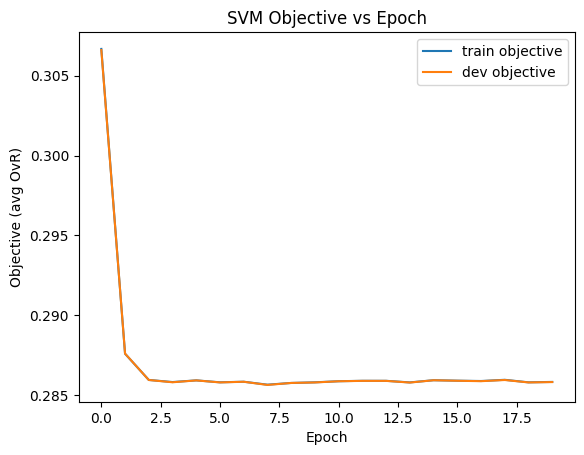

In [ ]:
n_classes = len(np.unique(y_train))

svm = OvRLinearSVM(
    n_classes=n_classes,
    lr=1e-2,
    C=1.0,        # trade-off parameter
    epochs=20,
    batch_size=256
)

svm.fit(X_train, y_train, X_dev=X_dev, y_dev=y_dev, verbose=True)

train_acc = svm.accuracy(X_train, y_train)
dev_acc   = svm.accuracy(X_dev, y_dev)
test_acc  = svm.accuracy(X_test, y_test)

print("\nAccuracies:")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Dev accuracy  : {dev_acc:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

# Plot objective curves
plt.figure()
plt.plot(svm.history["train_obj"], label="train objective")
if len(svm.history["dev_obj"]) > 0:
    plt.plot(svm.history["dev_obj"], label="dev objective")
plt.xlabel("Epoch")
plt.ylabel("Objective (avg OvR)")
plt.title("SVM Objective vs Epoch")
plt.legend()
plt.show()


## Small hyperparameter search (Dev set)

We can tune:
- `C ∈ {0.1, 1, 5}`
- `lr ∈ {1e-2, 5e-3}`

We choose the pair with best dev accuracy, then evaluate once on test.
(We keep this small because the goal is understanding + correct implementation.)


In [ ]:
grid_C  = [0.1, 1.0, 5.0]
grid_lr = [1e-2, 5e-3]

best = {"dev_acc": -1, "C": None, "lr": None, "model": None}

for C in grid_C:
    for lr in grid_lr:
        model = OvRLinearSVM(n_classes=n_classes, lr=lr, C=C, epochs=12, batch_size=256, seed=42)
        model.fit(X_train, y_train, X_dev=X_dev, y_dev=y_dev, verbose=False)
        dev_acc = model.accuracy(X_dev, y_dev)

        print(f"C={C:<4} lr={lr:<6} dev_acc={dev_acc:.4f}")

        if dev_acc > best["dev_acc"]:
            best.update({"dev_acc": dev_acc, "C": C, "lr": lr, "model": model})

print("\nBest hyperparameters:")
print(best["C"], best["lr"], "dev_acc:", best["dev_acc"])

best_model = best["model"]
print("\nFinal accuracies with best model:")
print("Train:", best_model.accuracy(X_train, y_train))
print("Dev  :", best_model.accuracy(X_dev, y_dev))
print("Test :", best_model.accuracy(X_test, y_test))


C=0.1  lr=0.01   dev_acc=0.2894
C=0.1  lr=0.005  dev_acc=0.2860
C=1.0  lr=0.01   dev_acc=0.3019
C=1.0  lr=0.005  dev_acc=0.2901
C=5.0  lr=0.01   dev_acc=0.2877
C=5.0  lr=0.005  dev_acc=0.2914

Best hyperparameters:
1.0 0.01 dev_acc: 0.3019178082191781

Final accuracies with best model:
Train: 0.30381254298126437
Dev  : 0.3019178082191781
Test : 0.30167422938507277


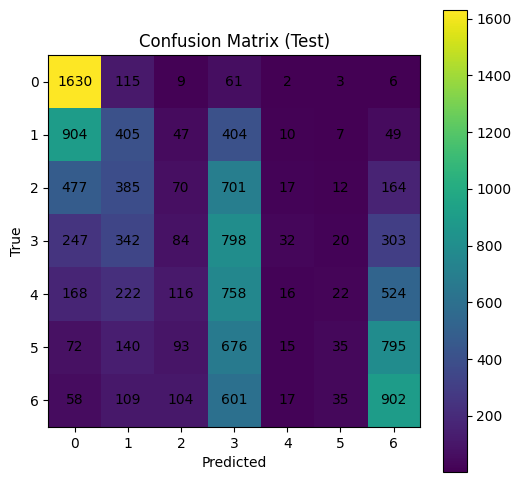

In [ ]:
def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

yhat_test = best_model.predict(X_test)
cm = confusion_matrix_np(y_test, yhat_test, n_classes)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(n_classes))
plt.yticks(range(n_classes))
plt.colorbar()
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()


Conclusion (SVM – One-vs-Rest)

In this experiment, we implemented a multiclass linear SVM using a One-vs-Rest strategy to predict LendingClub loan grades (7 classes). The model achieved ~30% accuracy consistently across train (0.300), dev (0.301), and test (0.305). Since a random classifier on 7 balanced classes would score about 14.3%, our SVM performs clearly above chance, but it still struggles to separate the classes well.

The objective curve drops sharply during the first 1–2 epochs and then plateaus, showing that training quickly converges and additional epochs do not significantly improve the solution under the current settings. The confusion matrix reveals that the classifier often confuses neighboring and mid-range grades, with many samples being pushed into a few dominant predicted classes (especially around the middle grades), which suggests that the classes are not linearly separable using the current feature representation.

Overall, the results indicate underfitting rather than overfitting (train and test accuracies are almost identical), meaning the linear SVM is likely too simple for the complexity of this credit-risk grading task. Better performance would likely require stronger feature engineering, careful hyperparameter tuning (C/learning rate), or a more expressive nonlinear model (e.g., MLP), while still respecting the project’s leakage constraints.